In [1]:
from pathlib import Path
from lightning.pytorch import seed_everything
import pandas as pd
import numpy as np
import torch
import scvi
import scanpy as sc
import squidpy as sq
import cellcharter as cc
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')

import readwrite
cfg = readwrite.config()
seed_everything(0)
torch.set_float32_matmul_precision('medium')

def concat_samples(ads, correction_method, segmentation, condition=None, panel=None):
    ads_corr_method = ads[correction_method]

    def is_match(key):
        return (
            segmentation in key and
            (condition is None or condition in key) and
            (panel is None or panel in key)
        )

    adata = sc.concat({k: v for k, v in ads_corr_method.items() if is_match(k)},label='dataset_id', join='outer')
    adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
    return adata

def subsample(adata, obs_key, n_obs, random_state=0, copy=True):
    """
    subsample each class to same cell numbers (N). Classes are given by obs_key pointing to categorical in adata.obs.
    """
    rs = np.random.RandomState(random_state)
    counts = adata.obs[obs_key].value_counts()

    indices = []
    for group, count in counts.items():
        idx = np.where(adata.obs[obs_key] == group)[0]

        if count <= n_obs:
            indices.extend(idx)
        else:
            indices.extend(rs.choice(idx, size=n_obs, replace=False))

    if copy:
        return adata[indices].copy()
    else:
        return adata[indices]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/work/PRTNR/CHUV/DIR/rgottar1/spatia

# Read results

In [2]:
xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

# input params
cellcharter_dir = 'cellcharter_cohort'
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'all'
panel = 'all'
normalisation = 'lognorm'
reference = 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'
xenium_levels = ['segmentation','condition','panel','donor','sample']

# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'
N_CLUSTERS_RANGE = (5,19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001

# output paths
wildcards = f"{cellcharter_dir}/{correction_method}/{segmentation}"
if cellcharter_dir != "cellcharter_cohort": 
    wildcards += f"/{condition}/{panel}"

OUTPUT_LABELS = results_dir/f'xenium/{wildcards}/labels.parquet'
OUTPUT_SCVI_MODEL = results_dir/f'xenium/{wildcards}/scvi_model'
OUTPUT_CELLCHARTER_MODELS = results_dir/f'xenium/{wildcards}/cellcharter_models'
OUTPUT_PLOT = results_dir/f'xenium/{wildcards}/autok_stability.png'
OUTPUT_X_SCVI = results_dir/f'xenium/{wildcards}/X_scvi.parquet'
OUTPUT_X_CELLCHARTER = results_dir/f'xenium/{wildcards}/X_cellcharter.parquet'



segmentations_filter=[segmentation]
conditions_filter=[condition] if condition != 'all' else None
panels_filter=[panel] if panel != 'all' else None

# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[correction_method])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(
        xenium_paths['raw'],  
        anndata=True, 
        pool_mode="thread",
        max_workers=6
    )

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# concat samples
adata = sc.concat({k: v for k, v in ads[correction_method].items() },label='dataset_id', join='outer')
adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
adata.obs['correction_method'] = correction_method


# add cellcharter results
# labels = pd.read_parquet(OUTPUT_LABELS).reset_index()
# adata.obs = adata.obs.reset_index().merge(labels,on=['index',*xenium_levels]).set_index('index')
# adata.obsm['X_cellcharter'] = X_cellcharter = pd.read_parquet(OUTPUT_X_SCVI).values
# adata.obsm['X_scvi'] = pd.read_parquet(OUTPUT_X_CELLCHARTER).values

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdat

Could not find annotation file for ('proseg_expected', 'CRC', 'hImmune_v1_mm', '131N', 'HCC_output-XETG00209__0003786__131N__20250503__073331'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC/hImmune_v1_mm/131N/HCC_output-XETG00209__0003786__131N__20250503__073331/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find annotation file for ('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1BI7', 'output-XETG00059__0003881__1BI7__20250505__170804'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO/hImmune_v1_dapi/1BI7/output-XETG00059__0003881__1BI7__20250505__170804/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find annotation file for ('proseg_expected', 'CRC', 'hImmune_v1_mm', '14V5', 'output-XETG00059__0053259__14V5__20250306__164822'

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
donors_crc = adata.obs.query("condition=='CRC'")['donor'].unique()
donors_crcpdo = adata.obs.query("condition=='CRC'")['donor'].unique()
donors = np.intersect1d(donors_crc,donors_crcpdo)

adata_shared_donors = adata[adata.obs['donor'].isin(donors)]
sc.pp.calculate_qc_metrics(adata_shared_donors, inplace=True,percent_top=False)


adata_shared_donors_malignant = adata_shared_donors[
    (adata_shared_donors[:,'EPCAM'].X.toarray().flatten()>1)
    & (adata_shared_donors.obs["total_counts"]>10)]

# adata_shared_donors_malignant_CRC = subsample(adata_shared_donors_malignant[adata_shared_donors_malignant.obs['condition']=='CRC'], obs_key='donor', n_obs=2000, copy=True)
# adata_shared_donors_malignant_CRC_PDO = subsample(adata_shared_donors_malignant[adata_shared_donors_malignant.obs['condition']=='CRC_PDO'], obs_key='donor', n_obs=2000, copy=True)
# adata_sub =  sc.concat((adata_shared_donors_malignant_CRC,adata_shared_donors_malignant_CRC_PDO))

sc.pp.normalize_total(adata_shared_donors_malignant)
sc.pp.log1p(adata_shared_donors_malignant)
sc.pp.pca(adata_shared_donors_malignant)

# sc.pp.neighbors(adata_sub,use_rep='X_scvi')
# sc.tl.umap(adata_sub)

# sc.pl.embedding(adata_sub, basis='X_scvi',color=['condition','donor']) 
# sc.pl.embedding(adata_sub, basis='X_umap',color=['condition','donor']) 

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scanpy/preprocessing/_qc.py:145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: U

In [ ]:
sc.pl.embedding(adata_sub[adata_sub.obs['condition']=='CRC'], basis='X_umap',color=['condition','donor']) 
sc.pl.embedding(adata_sub[adata_sub.obs['condition']=='CRC_PDO'], basis='X_umap',color=['condition','donor']) 

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view a

KeyError: "Could not find 'X_umap' or 'X_X_umap' in .obsm"

# bbknn

In [ ]:
sc.external.pp.bbknn(adata_shared_donors_malignant, batch_key='condition')
sc.tl.leiden(adata_shared_donors_malignant,flavor="igraph", n_iterations=2)

# adata_emb = sc.pp.sample(adata_shared_donors_malignant,n=50_000,copy=True,rng=0)
# sc.tl.umap(adata_emb)
# sc.pl.embedding(adata_emb, basis='X_umap',color=['condition','donor','EPCAM','total_counts','n_genes_by_counts'],ncols=2,vmin=0) 
# sc.pl.embedding(adata_emb[adata_emb.obs['condition']=='CRC'], basis='X_umap',color=['condition','donor']) 
# sc.pl.embedding(adata_emb[adata_emb.obs['condition']=='CRC_PDO'], basis='X_umap',color=['condition','donor']) 

/tmp/ipykernel_2696198/3627045708.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_shared_donors_malignant)


In [ ]:
adata_emb = sc.pp.sample(adata_shared_donors_malignant,n=50_000,copy=True,rng=0)
sc.tl.umap(adata_emb)
sc.pl.embedding(adata_emb, basis='X_umap',color=['condition','donor','EPCAM','total_counts','n_genes_by_counts'],ncols=2,vmin=0) 
sc.pl.embedding(adata_emb[adata_emb.obs['condition']=='CRC'], basis='X_umap',color=['condition','donor']) 
sc.pl.embedding(adata_emb[adata_emb.obs['condition']=='CRC_PDO'], basis='X_umap',color=['condition','donor']) 

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

--- 2. Transferring 'donor' labels from 'CRC' to 'CRC_PDO' ---
Processing query cell 15000/20000...
Label transfer complete.

--- 3. Evaluating Label Transfer: Confusion Matrix: Donor Label Transfer ---
Adjusted Rand Index (ARI): 0.1660


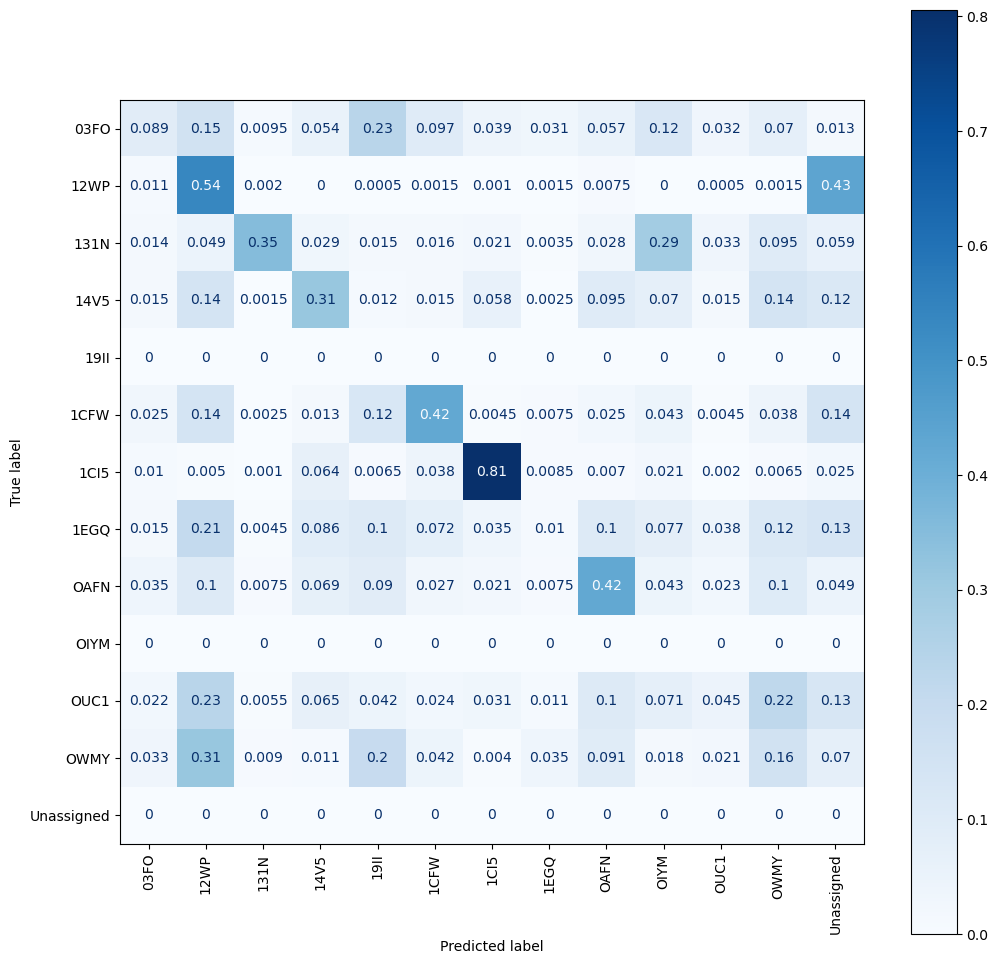

--- 3. Evaluating Label Transfer: Confusion Matrix: Donor Label Transfer ---
Adjusted Rand Index (ARI): 0.1660


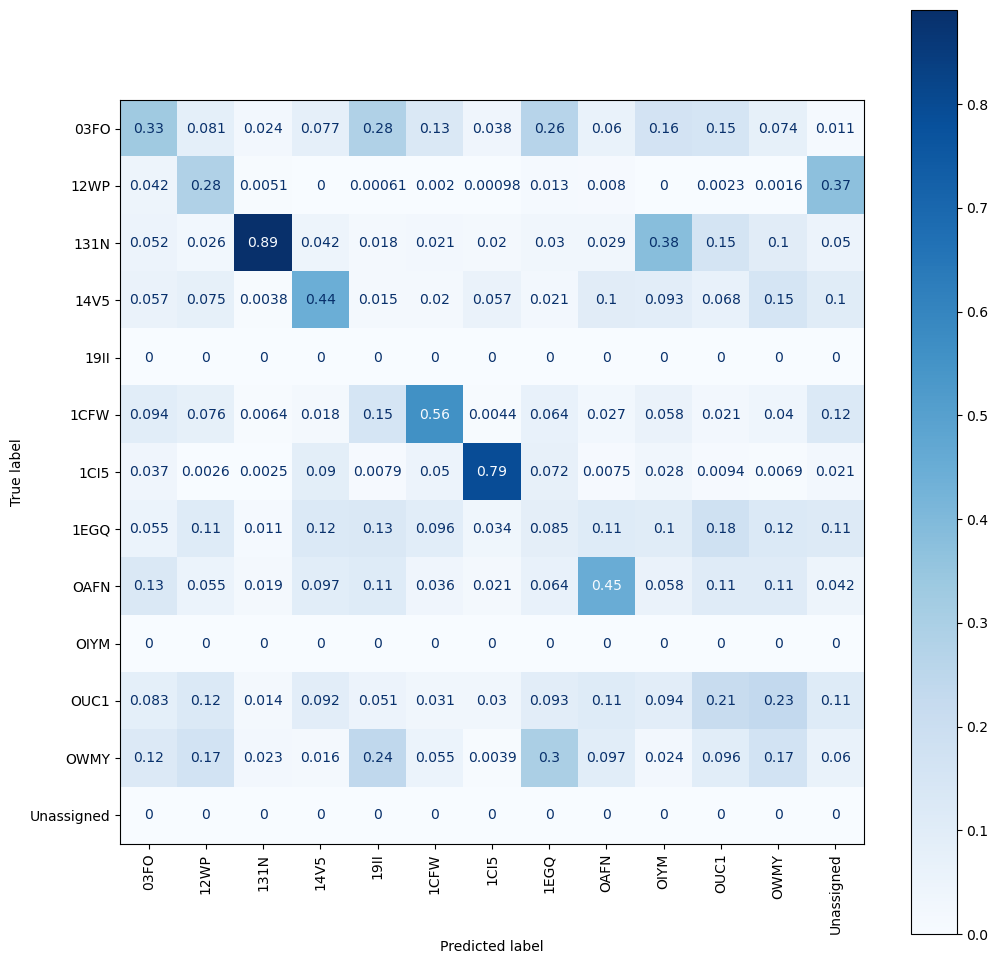

--- 3. Evaluating Label Transfer: Confusion Matrix: Donor Label Transfer ---
Adjusted Rand Index (ARI): 0.1660


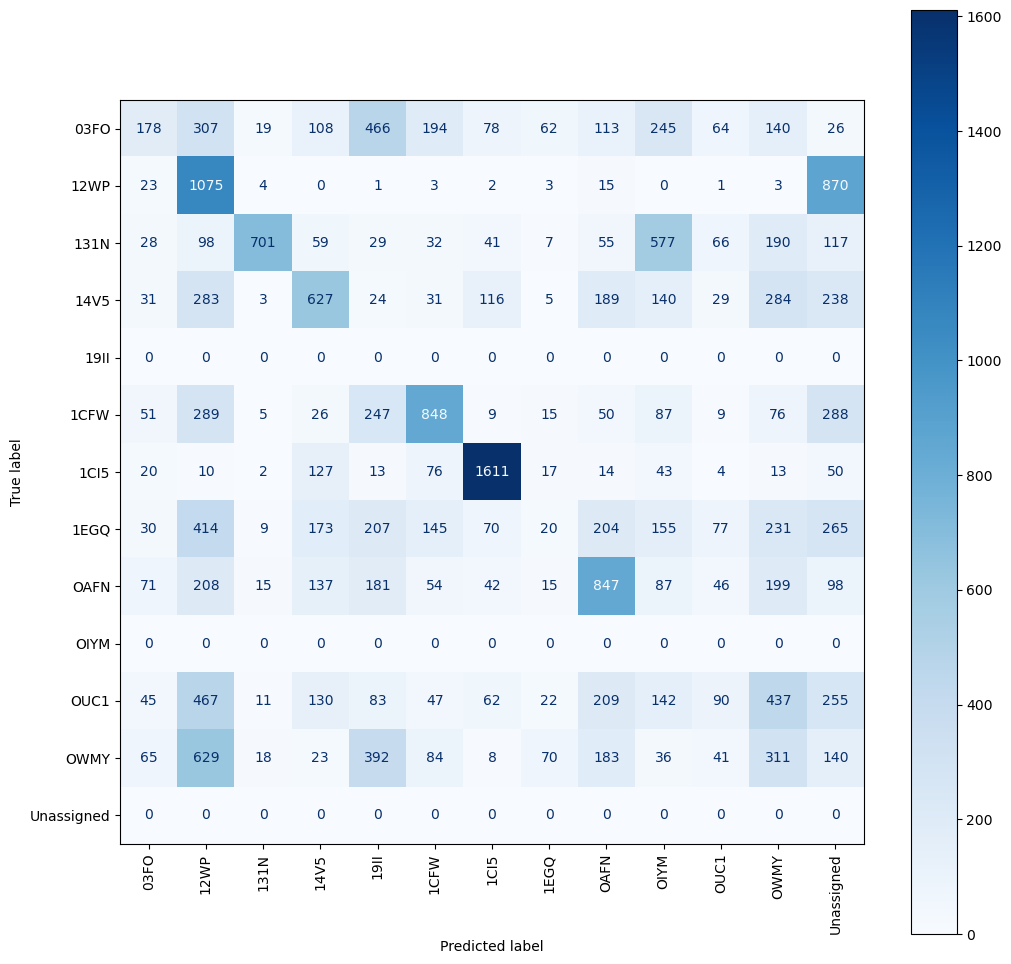

In [125]:
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt


def transfer_labels_from_graph(
    adata: sc.AnnData,
    ref_condition: str,
    query_condition: str,
    label_to_transfer: str,
    new_label_name: str = "predicted_label"
) -> pd.Series:
    """
    Transfers labels from a reference to a query group based on a kNN graph.

    For each cell in the query group, it finds its neighbors in the graph that
    belong to the reference group and assigns the most common label among them.

    Args:
        adata: The annotated data object containing the connectivity graph.
        ref_condition: The value in `adata.obs['condition']` for the reference cells.
        query_condition: The value in `adata.obs['condition']` for the query cells.
        label_to_transfer: The column name in `adata.obs` containing the labels to transfer.
        new_label_name: The column name to store the new predicted labels.

    Returns:
        pd.Series: A series containing the predicted labels for the query cells.
    """
    print(f"--- 2. Transferring '{label_to_transfer}' labels from '{ref_condition}' to '{query_condition}' ---")
    
    # Get the BBKNN connectivity matrix
    connectivities = adata.obsp['connectivities']

    # Get the indices for reference and query cells
    ref_indices = np.where(adata.obs['condition'] == ref_condition)[0]
    query_indices = np.where(adata.obs['condition'] == query_condition)[0]

    # Create a fast lookup for reference labels
    ref_labels = adata.obs[label_to_transfer].iloc[ref_indices]

    # Store predicted labels
    predicted_labels = []

    # Loop through each query cell to find its neighbors and predict its label
    for i, query_idx in enumerate(query_indices):
        if (i + 1) % 15000 == 0:
            print(f"Processing query cell {i+1}/{len(query_indices)}...")

        connections = connectivities[query_idx, :]
        neighbor_indices = connections.indices
        
        # Filter for neighbors that are in the reference group
        is_ref_neighbor = np.isin(neighbor_indices, ref_indices)
        ref_neighbor_indices = neighbor_indices[is_ref_neighbor]

        if len(ref_neighbor_indices) > 0:
            # Find the original positions of these neighbors within the ref_labels Series
            # searchsorted is very fast for this.
            positions_in_ref = np.searchsorted(ref_indices, ref_neighbor_indices)
            neighbor_actual_labels = ref_labels.iloc[positions_in_ref]
            
            # Majority vote to find the most common label
            most_common_label = neighbor_actual_labels.mode()[0]
            predicted_labels.append(most_common_label)
        else:
            # Handle cells with no reference neighbors
            predicted_labels.append('Unassigned')
            
    # Add the new labels to the AnnData object
    adata.obs[new_label_name] = 'N/A' # Initialize column
    adata.obs.loc[adata.obs['condition'] == query_condition, new_label_name] = predicted_labels
    
    print("Label transfer complete.\n")
    return adata.obs.loc[adata.obs['condition'] == query_condition, new_label_name]

def evaluate_label_transfer(
    true_labels: pd.Series,
    predicted_labels: pd.Series,
    title: str = "Label Transfer Evaluation",
    normalize: str = 'true' # Options: 'true', 'pred', 'all', or None
):
    """
    Calculates performance metrics and plots a confusion matrix to
    evaluate the quality of a label transfer.

    Args:
        true_labels: A pandas Series with the ground truth labels.
        predicted_labels: A pandas Series with the predicted labels.
        title: The title for the plot and output.
        normalize: How to normalize the confusion matrix.
                   - 'true': Normalize by row (shows recall).
                   - 'pred': Normalize by column (shows precision).
                   - 'all': Normalize by the total number of cells.
                   - None: Show raw counts.
    """
    print(f"--- 3. Evaluating Label Transfer: {title} ---")
    
    # Calculate Adjusted Rand Index (remains the same)
    ari_score = adjusted_rand_score(true_labels, predicted_labels)
    print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
    
    # Get a complete list of all possible labels for the matrix axes
    all_labels = sorted(list(set(true_labels.unique()) | set(predicted_labels.unique())))

    # --- UPDATED NORMALIZATION LOGIC ---
    # Create the confusion matrix using scikit-learn
    # cm = confusion_matrix(true_labels, predicted_labels, labels=all_labels)
    
    # The `normalize` parameter in ConfusionMatrixDisplay handles this perfectly
    fig, ax = plt.subplots(figsize=(12, 12))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=true_labels,
        y_pred=predicted_labels,
        labels=all_labels,
        normalize=normalize, # Pass the normalization option here
        cmap='Blues',
        xticks_rotation='vertical',
        ax=ax
    )

    plt.show()


predicted_donors = transfer_labels_from_graph(
    adata=adata_sub,
    ref_condition='CRC',
    query_condition='CRC_PDO',
    label_to_transfer='donor',
    new_label_name='predicted_donor'
)
true_donors = adata_sub.obs.loc[adata_sub.obs['condition'] == 'CRC_PDO','donor']


# Plot 1: Normalize by row (most common) to show recall
evaluate_label_transfer(
    true_labels=true_donors,
    predicted_labels=predicted_donors,
    title="Confusion Matrix: Donor Label Transfer",
    normalize='true' # Normalize by the true label (row-wise)
)

# Plot 2: Normalize by column to show precision
evaluate_label_transfer(
    true_labels=true_donors,
    predicted_labels=predicted_donors,
    title="Confusion Matrix: Donor Label Transfer",
    normalize='pred' # Normalize by the predicted label (column-wise)
)

# Plot 3: Show raw counts
evaluate_label_transfer(
    true_labels=true_donors,
    predicted_labels=predicted_donors,
    title="Confusion Matrix: Donor Label Transfer",
    normalize=None # Show the raw counts
)

# OT


--- 2. Finding Best UOT Parameter ---
Calculating cost matrix...

Testing rho = 0.1...


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Balanced Accuracy: 0.4725
  ARI: 0.2978

--- 3. Optimal Parameter Found ---
Best rho: 0.1
Best Balanced Accuracy: 0.4725
Corresponding ARI: 0.2978

--- 4. Visualizing Best Result ---


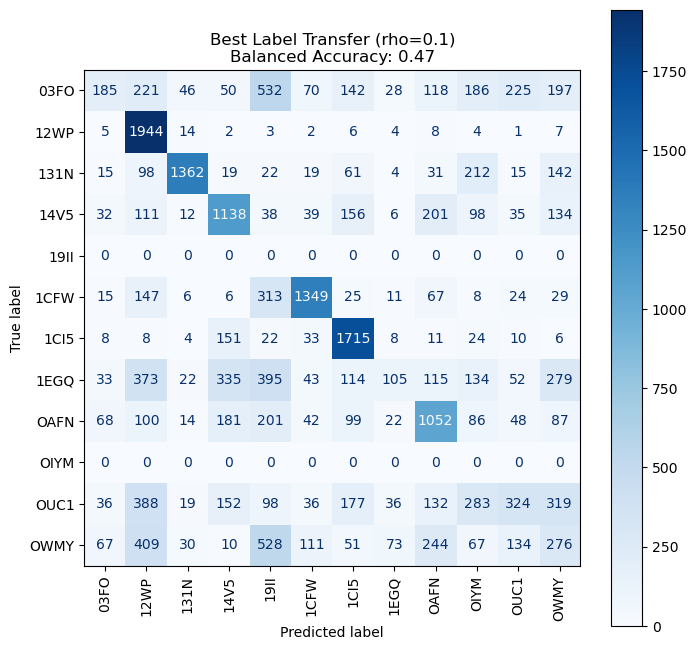

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import ot
from sklearn.metrics import adjusted_rand_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def transfer_labels_with_ot(
    transport_matrix: np.ndarray,
    ref_labels: pd.Series
) -> pd.Series:
    """
    Transfers labels from a reference to a query set using a transport matrix.

    For each query cell, it identifies the reference cell it is most strongly
    mapped to and assigns its label.

    Args:
        transport_matrix: The (n_query, n_ref) coupling matrix from OT.
                          Rows sum to the weights of the query samples.
        ref_labels: A pandas Series of labels for the reference samples.

    Returns:
        pd.Series: The predicted labels for the query samples.
    """
    # Find the reference cell with the highest transport mass for each query cell
    # np.argmax finds the index of the maximum value along an axis.
    best_match_indices = np.argmax(transport_matrix, axis=1)
    
    # Map these indices to the reference labels
    predicted_labels = ref_labels.iloc[best_match_indices].values
    
    return pd.Series(predicted_labels)


def find_best_ot_parameter(
    adata_ref: sc.AnnData,
    adata_query: sc.AnnData,
    label_key: str = "true_label",
    embedding_key: str = "X_pca",
    rho_values: list = [0.1, 1, 10, 100],
    epsilon: float = 0.1
):
    """
    Performs a grid search over the unbalanced OT parameter 'rho' to find
    the value that maximizes label transfer accuracy.

    Args:
        adata_ref: AnnData object for the reference dataset.
        adata_query: AnnData object for the query dataset.
        label_key: The .obs key containing the ground truth labels.
        embedding_key: The .obsm key for the embedding to use for distance calculation.
        rho_values: A list of 'rho' values to test. Rho balances mass preservation and KL divergence.
        epsilon: The entropy regularization term. A small value is good for label transfer.
    """
    print("\n--- 2. Finding Best UOT Parameter ---")
    
    # Extract embeddings and labels
    X_ref = adata_ref.obsm[embedding_key]
    y_ref = adata_ref.obs[label_key]
    X_query = adata_query.obsm[embedding_key]
    y_query_true = adata_query.obs[label_key]
    
    # Calculate the cost matrix (squared Euclidean distance) between all cells
    print("Calculating cost matrix...")
    cost_matrix = ot.dist(X_query, X_ref, metric='sqeuclidean')
    cost_matrix /= cost_matrix.max() # Normalize for stability

    # We assume uniform weights for all cells initially
    a = np.ones(X_query.shape[0]) / X_query.shape[0] # Query weights
    b = np.ones(X_ref.shape[0]) / X_ref.shape[0]   # Reference weights
    
    results = []
    
    # Iterate over the grid of parameters
    for rho in rho_values:
        print(f"\nTesting rho = {rho}...")
        
        # Compute the Unbalanced Optimal Transport plan
        try:
            transport_plan = ot.unbalanced.sinkhorn_unbalanced(
                a, b, cost_matrix, epsilon, rho, verbose=False
            )
            
            # Transfer labels using the transport plan
            y_query_pred = transfer_labels_with_ot(transport_plan, y_ref)
            
            # Evaluate the transfer
            ari = adjusted_rand_score(y_query_true, y_query_pred)
            bal_acc = balanced_accuracy_score(y_query_true, y_query_pred)
            
            print(f"  Balanced Accuracy: {bal_acc:.4f}")
            print(f"  ARI: {ari:.4f}")
            
            results.append({
                'rho': rho,
                'balanced_accuracy': bal_acc,
                'ari': ari,
                'transport_plan': transport_plan # Save the plan for later
            })
            
        except Exception as e:
            print(f"  Failed to compute for rho={rho}. Error: {e}")

    # Find the best result based on balanced accuracy
    if not results:
        print("No successful runs. Exiting.")
        return

    best_result = max(results, key=lambda x: x['balanced_accuracy'])
    
    print("\n--- 3. Optimal Parameter Found ---")
    print(f"Best rho: {best_result['rho']}")
    print(f"Best Balanced Accuracy: {best_result['balanced_accuracy']:.4f}")
    print(f"Corresponding ARI: {best_result['ari']:.4f}")

    # Visualize the confusion matrix for the best result
    print("\n--- 4. Visualizing Best Result ---")
    best_y_pred = transfer_labels_with_ot(best_result['transport_plan'], y_ref)
    
    all_labels = sorted(list(set(y_query_true.unique()) | set(best_y_pred.unique())))
    cm = confusion_matrix(y_query_true, best_y_pred, labels=all_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
    title = f"Best Label Transfer (rho={best_result['rho']})\nBalanced Accuracy: {best_result['balanced_accuracy']:.2f}"
    plt.title(title)
    plt.show()


# Prepare the data
adata_ref = adata_sub[adata_sub.obs['condition']=='CRC'].copy()
adata_query = adata_sub[adata_sub.obs['condition']=='CRC_PDO'].copy()

# Define the parameter grid to search
# A wider range might be needed for real data
rho_grid = [0.1]

# Find the best parameter and evaluate
find_best_ot_parameter(
    adata_ref,
    adata_query,
    rho_values=rho_grid,
    epsilon=0.1, # Epsilon is the entropy regularization. 0.1 is a good starting point.,
    label_key='donor'
)


--- Aligning Datasets with Gaussian Gromov-Wasserstein (GGW) Mapping ---
Computing the GGW linear map...


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/ot/da.py:692: RuntimeWarning: invalid value encountered in divide
  transp = self.coupling_ / nx.sum(self.coupling_, axis=1)[:, None]


Training kNN classifier and predicting labels...

--- Evaluation Results ---
Balanced Accuracy: 0.3296
ARI: 0.1386


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/tmp/ipykernel_4043745/3754417089.py:69: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_combined_aligned = adata_ref.concatenate(adata_query_transformed, batch_key='source_dataset')


Computing UMAP for visualization...
Plotting results...


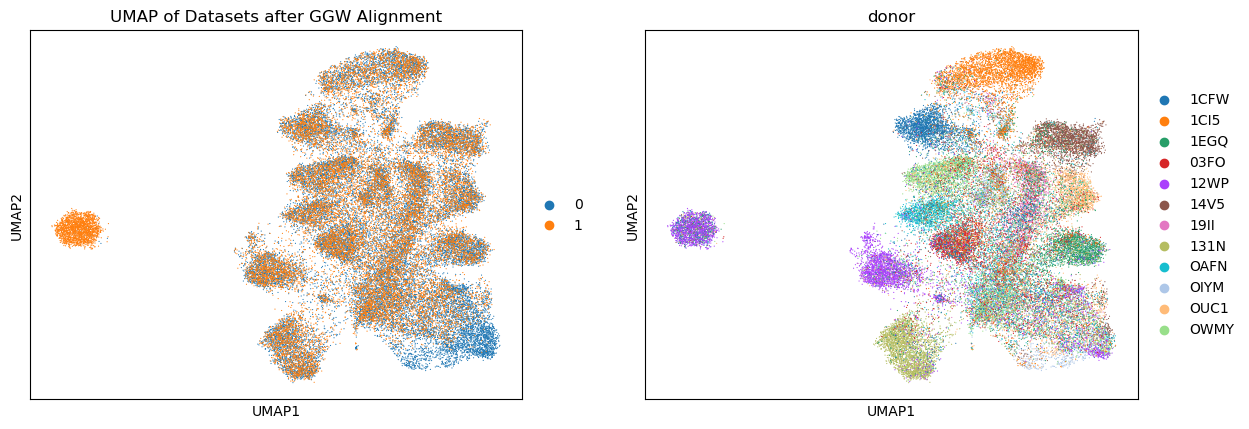

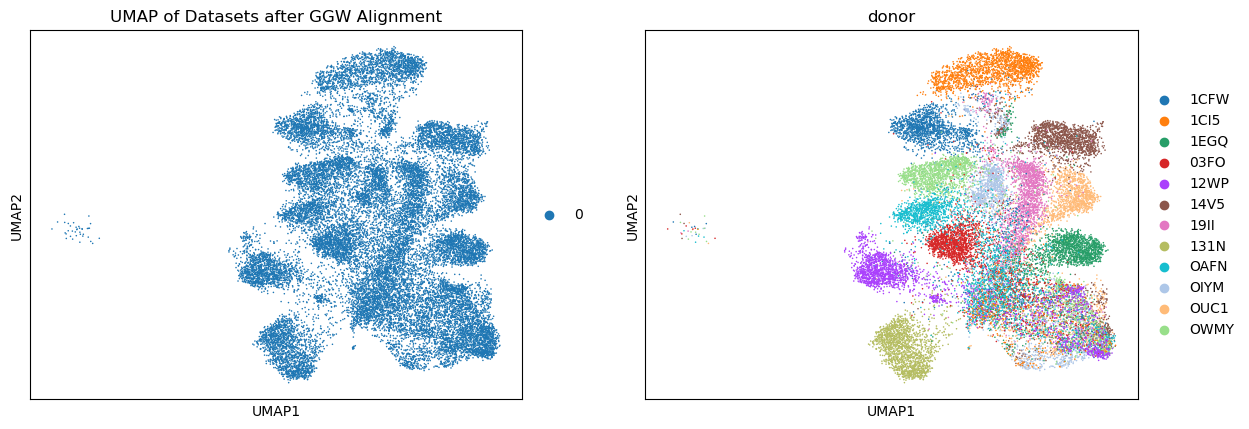

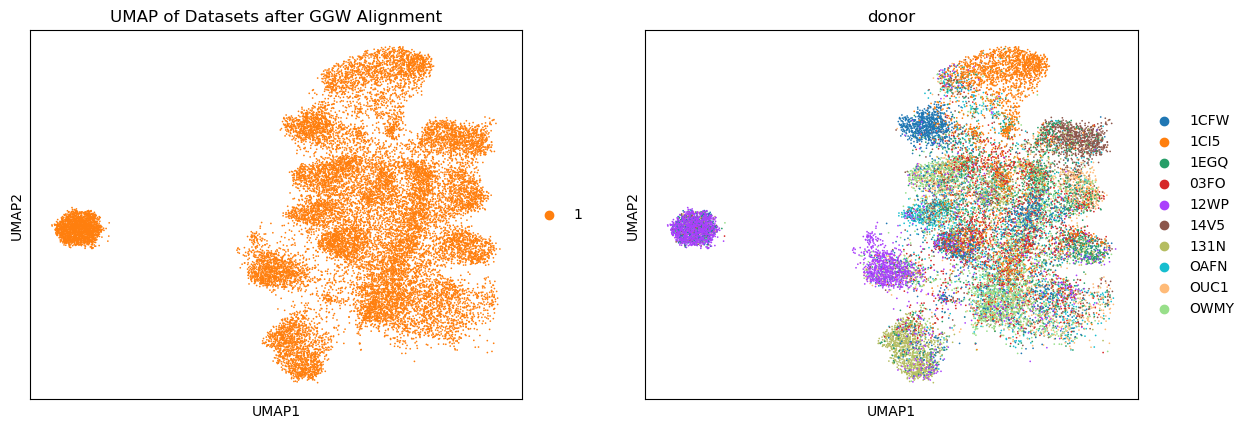

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def align_and_evaluate_ggw(
    adata_ref: sc.AnnData,
    adata_query: sc.AnnData,
    label_key: str = "true_label",
    embedding_key: str = "X_pca",
):
    """
    Aligns two datasets using Gaussian Gromov-Wasserstein linear mapping and
    evaluates the alignment via label transfer.

    This method does not require hyperparameter tuning.
    """
    print("\n--- Aligning Datasets with Gaussian Gromov-Wasserstein (GGW) Mapping ---")
    
    # 1. Extract full embeddings and labels
    X_ref = adata_ref.obsm[embedding_key]
    y_ref = adata_ref.obs[label_key]
    X_query = adata_query.obsm[embedding_key]
    y_query_true = adata_query.obs[label_key]

    # 2. Compute the optimal linear map using GGW
    # This is the core function call. It directly solves for the transformation.
    print("Computing the GGW linear map...")
    # A_ggw, b_ggw = ot.gaussian.empirical_gaussian_gromov_wasserstein_mapping(
    #     xs=X_query, 
    #     xt=X_ref
    # )
    
    # # 3. Apply the transformation to the entire query set
    # # The transformation is T(x) = x @ A.T + b
    # print("Transforming the full query dataset...")
    # X_query_transformed = X_query @ A_ggw.T + b_ggw

    n = len(X_query)
    m = len(X_ref)
    mu_s, mu_t = np.ones(n) / n, np.ones(m) / m  # uniform distribution on samples

    # transp = ot.da.EMDTransport()
    transp=ot.da.EMDTransport()
    transp.mu_s = mu_s
    transp.mu_t = mu_t
    X_query_transformed = transp.fit_transform(Xs=X_query, Xt=X_ref)

    
    # 4. Evaluate the alignment with a kNN classifier
    print("Training kNN classifier and predicting labels...")
    knn_classifier = KNeighborsClassifier(n_neighbors=15)
    knn_classifier.fit(X_ref, y_ref)
    y_query_pred = knn_classifier.predict(X_query_transformed)
    
    # --- Evaluation ---
    print("\n--- Evaluation Results ---")
    bal_acc = balanced_accuracy_score(y_query_true, y_query_pred)
    ari = adjusted_rand_score(y_query_true, y_query_pred)
    
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ARI: {ari:.4f}")

    # Visualize with a UMAP of the aligned data
    # Create a new anndata object for visualization
    adata_query_transformed = adata_query.copy()
    adata_query_transformed.obsm['X_aligned'] = X_query_transformed
    
    adata_ref.obsm['X_aligned'] = X_ref # Add the same key to the ref
    
    # Concatenate for plotting
    adata_combined_aligned = adata_ref.concatenate(adata_query_transformed, batch_key='source_dataset')
    
    print("Computing UMAP for visualization...")
    sc.pp.neighbors(adata_combined_aligned, use_rep='X_aligned')
    sc.tl.umap(adata_combined_aligned)
    
    print("Plotting results...")
    sc.pl.umap(
        adata_combined_aligned,
        color=['source_dataset', label_key],
        title='UMAP of Datasets after GGW Alignment'
    )


    return adata_combined_aligned
    
adata_combined_aligned = align_and_evaluate_ggw(adata_ref, adata_query, label_key='donor')

sc.pl.umap(
    adata_combined_aligned[adata_combined_aligned.obs['condition'] == 'CRC'],
    color=['source_dataset', 'donor'],
    title='UMAP of Datasets after GGW Alignment'
)
sc.pl.umap(
    adata_combined_aligned[adata_combined_aligned.obs['condition'] == 'CRC_PDO'],
    color=['source_dataset', 'donor'],
    title='UMAP of Datasets after GGW Alignment'
)

In [ ]:
 #adata_combined_aligned#.obs['n_counts']

AnnData object with n_obs × n_vars = 44000 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'dataset_id', 'segmentation', 'condition', 'panel', 'donor', 'sample', 'correction_method_x', 'correction_method_y', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', 'predicted_donor', 'source_dataset'
    uns: 'neighbors', 'umap', 'source_dataset_colors', 'donor_colors'
    obsm: 'spatial', 'X_cellcharter', 'X_scvi', 'X_pca', 'X_umap', 'X_aligned'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.pl.umap(
    adata_combined_aligned,
    color=[],
    title='UMAP of Datasets after GGW Alignment'
)

In [ ]:
# for d in adata.obs['donor'].unique():
#     sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)